# Modelado: pronóstico de demanda a 14 días
## Demanda diaria (`units_sold`) por tienda x categoría

**Problema de negocio:** pronosticar las unidades vendidas por tienda y categoría con
**14 días de anticipación**, para alimentar la reposición de inventario (cobertura de un
ciclo de quincena completo). El sistema actual (`replenishment_signal`) no sirve para
esto: se calcula con la demanda del mismo día (ver EDA, sección 10).

**Diseño anti-leakage:** para predecir el día *t* solo se usa información disponible en
*t − 14*. Todos los lags y ventanas móviles están desplazados ≥ 14 días
(ver `src/features.py`).

**Validación:** 4 folds de origen rodante, ventanas de prueba de 14 días consecutivas
(2024-01-05 a 2024-02-29). Cada fold entrena únicamente con el pasado.

**Métricas:** WMAPE (% de error sobre demanda total), MAE (unidades) y sesgo
(>0 = sobre-stock, <0 = riesgo de quiebre).

**Contenido:**

1. Configuración y construcción del dataset
2. Baselines
3. Modelo LightGBM
4. Comparación de resultados
5. Desagregación por categoría y formato
6. Importancia de features
7. Traducción a valor de negocio
8. Conclusiones

## 1. Configuración y construcción del dataset

In [12]:
import sys
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("..")  # para importar src/ desde notebooks/
from src.features import build_dataset, TARGET
from src.metrics import evaluate, wmape
from src.validation import rolling_origin_splits

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
HORIZON = 14
N_FOLDS = 4

In [13]:
# Pipeline de features (ver src/features.py): panel completo, lags >= 14 días,
# calendario y atributos de tienda. Excluye replenishment_signal por leakage.
panel, FEATURES = build_dataset(data_dir="../data", horizon=HORIZON)
print(f"Dataset: {panel.shape[0]:,} filas | {len(FEATURES)} features")
print(FEATURES)

Dataset: 204,000 filas | 27 features
['category', 'has_promotion', 'lag_14', 'lag_21', 'lag_28', 'rmean_7_h14', 'rstd_7_h14', 'rmean_28_h14', 'rstd_28_h14', 'day_of_week', 'week_of_year', 'month', 'quarter', 'is_holiday', 'is_payday', 'is_weekend', 'is_navidad_season', 'is_buen_fin', 'is_semana_santa', 'store_format', 'region', 'size_sqm', 'num_checkouts', 'socioeconomic_level', 'has_pharmacy', 'has_fuel_station', 'store_age_years']


## 2. Baselines

Sin un punto de comparación simple no se puede demostrar que un modelo aporta valor.

- **Naive estacional:** demanda del mismo día de la semana hace 14 días (`lag_14`).
- **Media móvil:** promedio de los últimos 28 días disponibles al momento de predecir
  (`rmean_28_h14`).

In [14]:
BASELINES = {"naive_14d": "lag_14", "media_movil_28d": "rmean_28_h14"}

resultados = []  # métricas por fold y método
predicciones_ultimo_fold = None

for tr_mask, te_mask, ini, fin in rolling_origin_splits(panel["date"], n_folds=N_FOLDS, test_days=HORIZON):
    test = panel[te_mask & panel[TARGET].notna()]
    for nombre, col in BASELINES.items():
        sub = test.dropna(subset=[col])
        resultados.append({
            "fold": f"{ini.date()}", "metodo": nombre,
            "wmape": wmape(sub[TARGET], sub[col]),
            "mae": float((sub[TARGET] - sub[col]).abs().mean()),
        })

pd.DataFrame(resultados).pivot(index="fold", columns="metodo", values="wmape").round(4)

metodo,media_movil_28d,naive_14d
fold,,
2024-01-05,0.969,1.352
2024-01-19,0.815,0.333
2024-02-02,0.368,0.330
2024-02-16,0.290,0.322


## 3. Modelo LightGBM

Gradient boosting sobre el panel: captura interacciones entre calendario, tienda y
demanda histórica que los baselines no ven. Objetivo L1 (alineado con WMAPE/MAE).
Se entrena un modelo por fold, siempre solo con datos anteriores a la ventana de prueba.

In [15]:
LGB_PARAMS = {
    "objective": "regression_l1",
    "n_estimators": 800,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 50,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "subsample_freq": 1,
    "random_state": SEED,
    "verbose": -1,
}

preds_folds = []   # predicciones de test de todos los folds
modelos = []

for tr_mask, te_mask, ini, fin in rolling_origin_splits(panel["date"], n_folds=N_FOLDS, test_days=HORIZON):
    # entrenar solo con target observado (se excluyen filas imputadas)
    train = panel[tr_mask & panel[TARGET].notna()]
    test = panel[te_mask & panel[TARGET].notna()].copy()

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(train[FEATURES], train[TARGET])
    modelos.append(model)

    test["pred_lgbm"] = np.clip(model.predict(test[FEATURES]), 0, None)  # demanda no negativa
    test["fold"] = str(ini.date())
    preds_folds.append(test)

    resultados.append({
        "fold": f"{ini.date()}", "metodo": "lgbm",
        "wmape": wmape(test[TARGET], test["pred_lgbm"]),
        "mae": float((test[TARGET] - test["pred_lgbm"]).abs().mean()),
    })

preds = pd.concat(preds_folds, ignore_index=True)
print(f"Predicciones generadas: {len(preds):,} filas en {N_FOLDS} folds")

Predicciones generadas: 26,045 filas en 4 folds


## 4. Comparación de resultados

In [16]:
tabla = pd.DataFrame(resultados)
comparacion = tabla.pivot(index="fold", columns="metodo", values="wmape")
comparacion.loc["PROMEDIO"] = comparacion.mean()
display(comparacion.round(4))

mejora = 100 * (1 - comparacion.loc["PROMEDIO", "lgbm"] / comparacion.loc["PROMEDIO", "naive_14d"])
print(f"Mejora del modelo vs baseline naive: {mejora:.1f}% de reducción en WMAPE")

metodo,lgbm,media_movil_28d,naive_14d
fold,,,
2024-01-05,0.424,0.969,1.352
2024-01-19,0.310,0.815,0.333
2024-02-02,0.238,0.368,0.330
2024-02-16,0.235,0.290,0.322
PROMEDIO,0.302,0.611,0.584


Mejora del modelo vs baseline naive: 48.4% de reducción en WMAPE


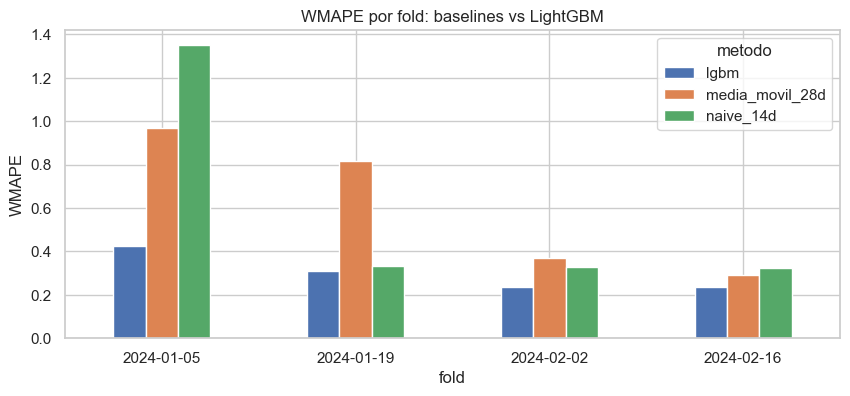

In [17]:
ax = comparacion.drop(index="PROMEDIO").plot(kind="bar", figsize=(10, 4),
                                             title="WMAPE por fold: baselines vs LightGBM")
ax.set_ylabel("WMAPE")
ax.tick_params(axis="x", rotation=0)
plt.show()

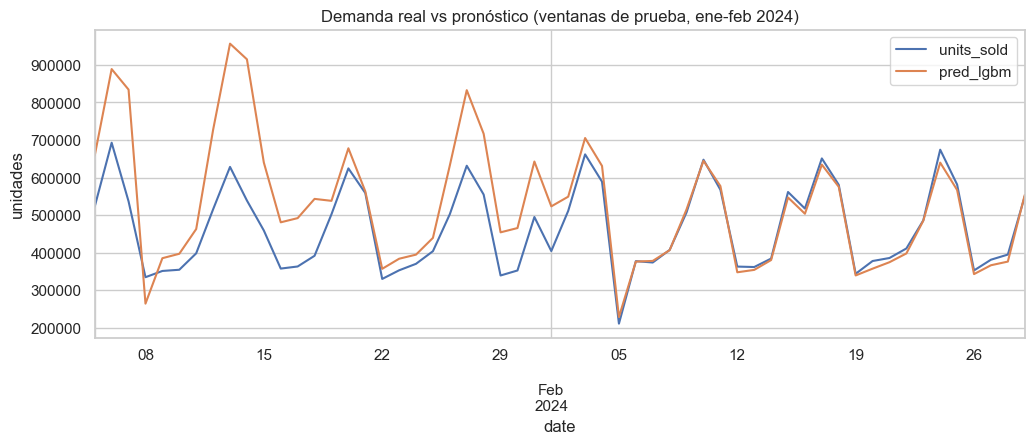

In [18]:
# Pronóstico vs real agregado (todos los folds de prueba)
agg = preds.groupby("date")[[TARGET, "pred_lgbm"]].sum()
ax = agg.plot(title="Demanda real vs pronóstico (ventanas de prueba, ene-feb 2024)")
ax.set_ylabel("unidades")
plt.show()

## 5. Desagregación por categoría y formato

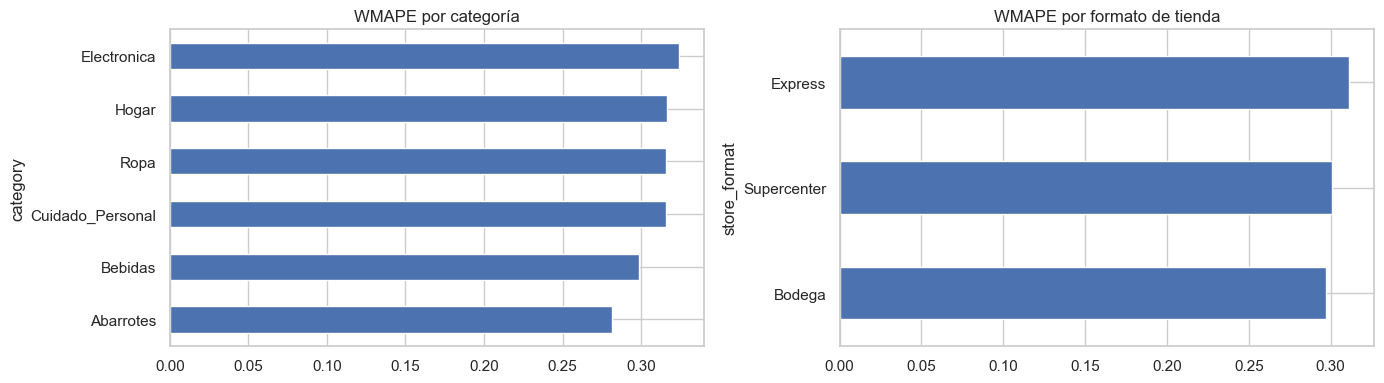

,wmape,mae,bias,n
category,,,,
Abarrotes,0.281,543.802,0.096,"4,333.000"
Bebidas,0.299,449.282,0.126,"4,351.000"
Cuidado_Personal,0.316,303.892,0.157,"4,347.000"
Ropa,0.316,169.546,0.158,"4,336.000"
Hogar,0.317,236.627,0.142,"4,341.000"
Electronica,0.324,103.428,0.167,"4,337.000"


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_cat = evaluate(preds, TARGET, "pred_lgbm", by="category").sort_values("wmape")
por_fmt = evaluate(preds, TARGET, "pred_lgbm", by="store_format").sort_values("wmape")
por_cat["wmape"].plot(kind="barh", ax=axes[0], title="WMAPE por categoría")
por_fmt["wmape"].plot(kind="barh", ax=axes[1], title="WMAPE por formato de tienda")
plt.tight_layout()
plt.show()
display(por_cat.round(3))

### 5.1 Análisis de errores: ¿cuándo falla el modelo?

El WMAPE por fold no es homogéneo: el primer fold (5-18 ene) es notablemente peor.
Analizamos el error día a día y el sesgo por fold para entender dónde y en qué
dirección se equivoca el modelo — esto determina el riesgo operativo
(sobre-stock vs quiebre) y los siguientes pasos.

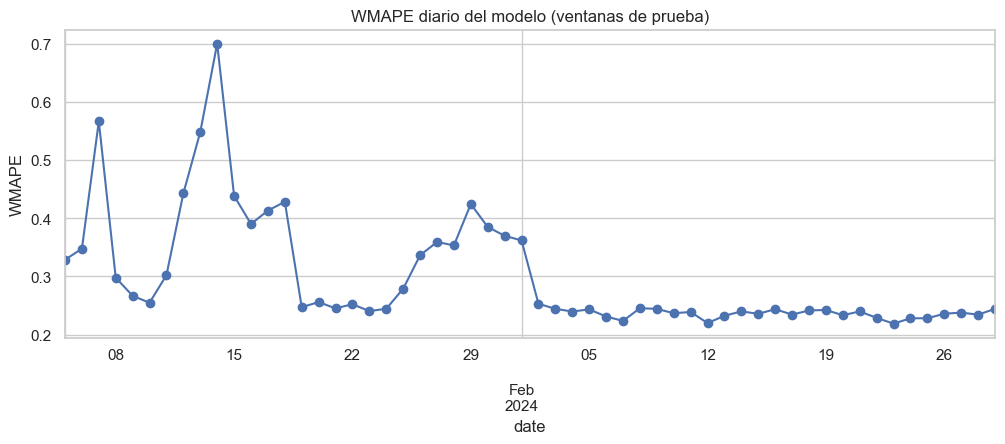

Sesgo por fold (>0 = sobre-pronóstico):
fold
2024-01-05    0.342
2024-01-19    0.187
2024-02-02    0.018
2024-02-16   -0.026


In [20]:
# WMAPE diario del modelo en las ventanas de prueba.
# Hipótesis: el fold post-navideño es el más difícil porque la demanda cae
# bruscamente tras el pico de diciembre y los lags de 14-28 días aún lo reflejan.
diario = preds.groupby("date").apply(lambda g: wmape(g[TARGET], g["pred_lgbm"])).rename("wmape_lgbm")
ax = diario.plot(marker="o", title="WMAPE diario del modelo (ventanas de prueba)")
ax.set_ylabel("WMAPE")
plt.show()

# Sesgo por fold: >0 = sobre-pronóstico (riesgo de sobre-stock)
from src.metrics import bias
sesgo = preds.groupby("fold").apply(lambda g: bias(g[TARGET], g["pred_lgbm"])).rename("sesgo")
print("Sesgo por fold (>0 = sobre-pronóstico):")
print(sesgo.round(3).to_string())

## 6. Importancia de features

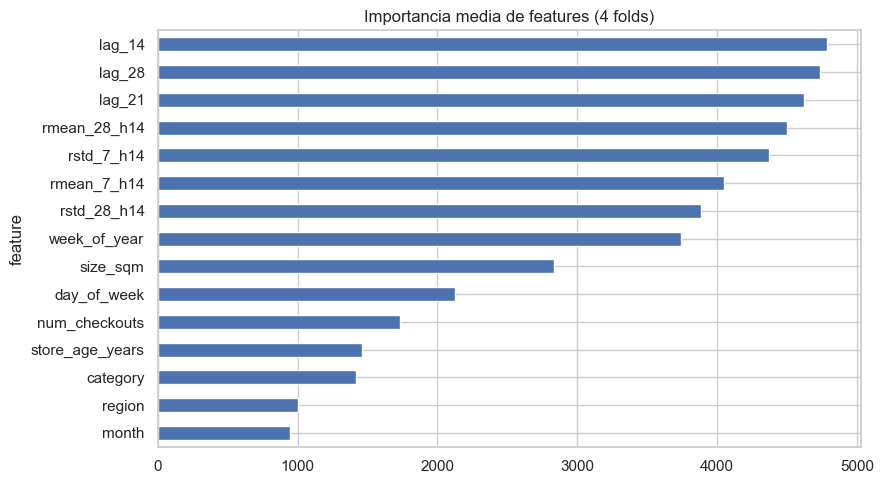

In [21]:
imp = pd.DataFrame({
    "feature": FEATURES,
    "importancia": np.mean([m.feature_importances_ for m in modelos], axis=0),
}).sort_values("importancia", ascending=True)

imp.tail(15).plot(kind="barh", x="feature", y="importancia", legend=False,
                  figsize=(9, 5), title="Importancia media de features (4 folds)")
plt.tight_layout()
plt.show()

## 7. Traducción a valor de negocio

El error en unidades se traduce a pesos usando el precio medio por unidad de cada
categoría (mediana histórica de `amount_total / units_sold`). La reducción de error
vs el baseline aproxima el valor de la mejora: menos sobre-stock (capital inmovilizado,
merma) y menos quiebres (venta perdida).

In [22]:
# Precio proxy por categoría (solo datos de entrenamiento del primer fold para no contaminar)
trx = pd.read_csv("../data/transactions.csv", parse_dates=["date"])
precio = (
    trx[trx["date"] < "2024-01-05"]
    .assign(precio_unit=lambda d: d["amount_total"] / d["units_sold"])
    .groupby("category")["precio_unit"].median()
    .rename("precio_unitario_mxn")
)

err = preds.copy()
err["ae_lgbm"] = (err[TARGET] - err["pred_lgbm"]).abs()
err["ae_naive"] = (err[TARGET] - err["lag_14"]).abs()

valor = (
    err.groupby("category", observed=True)[["ae_lgbm", "ae_naive"]].sum()
    .join(precio)
)
valor["error_evitado_unidades"] = valor["ae_naive"] - valor["ae_lgbm"]
valor["error_evitado_mxn"] = valor["error_evitado_unidades"] * valor["precio_unitario_mxn"]
display(valor.round(0))

total_mxn = valor["error_evitado_mxn"].sum()
dias_prueba = preds["date"].nunique()
print(f"Error de pronóstico evitado vs baseline: {total_mxn:,.0f} MXN "
      f"en {dias_prueba} días de prueba ({total_mxn / dias_prueba:,.0f} MXN/día "
      f"en las 80 tiendas)")

,ae_lgbm,ae_naive,precio_unitario_mxn,error_evitado_unidades,error_evitado_mxn
category,,,,,
Abarrotes,"2,356,293.000","4,896,494.000",113.000,"2,540,201.000","286,426,250.000"
Bebidas,"1,954,828.000","3,848,696.000",74.000,"1,893,868.000","140,109,960.000"
Cuidado_Personal,"1,321,019.000","2,376,338.000",95.000,"1,055,319.000","99,825,998.000"
Electronica,"448,567.000","819,115.000",486.000,"370,548.000","179,995,628.000"
Hogar,"1,027,197.000","1,873,639.000",195.000,"846,442.000","165,260,725.000"
Ropa,"735,152.000","1,340,119.000",266.000,"604,967.000","160,813,166.000"


Error de pronóstico evitado vs baseline: 1,032,431,727 MXN en 56 días de prueba (18,436,281 MXN/día en las 80 tiendas)


## 8. Conclusiones

### Resultados

| Método | WMAPE promedio (4 folds) |
|---|---|
| Naive estacional (14 días) | 58.4% |
| Media móvil 28 días | 61.1% |
| **LightGBM** | **30.2%** |

- El modelo **reduce el error de pronóstico 48.4%** frente al mejor baseline, con mejora consistente en los 4 folds (WMAPE 0.42 / 0.31 / 0.24 / 0.24).
- El fold post-navideño (5-18 ene) es el más difícil para todos los métodos: la demanda cae bruscamente tras diciembre y los lags aún reflejan el pico. Aun ahí, el modelo (0.42) supera por mucho al naive (1.35), que colapsa.
- Por categoría el desempeño es homogéneo (WMAPE 28-32%): mejor en `Abarrotes` (0.281, alto volumen y demanda estable), peor en `Electronica` (0.324, demanda más errática).
- **Sesgo positivo en todas las categorías (+0.10 a +0.17)**: en ene-feb el modelo tiende a sobre-pronosticar (entrenó con el pico navideño). Operativamente el riesgo es sobre-stock, no quiebre; es corregible con recalibración o mayor peso a observaciones recientes.
- La importancia de features está dominada por la demanda histórica (ventanas móviles y lags), seguida del calendario — consistente con un problema de forecasting bien planteado.

### Valor de negocio

Valuando el error en unidades al precio mediano por categoría, el modelo evita el equivalente a **~1,032 M MXN de error de pronóstico en 56 días de prueba** (~18.4 M MXN/día en 80 tiendas) frente al baseline naive. **Interpretación honesta:** esto no es ahorro directo; es la magnitud del desalineamiento inventario-demanda que se evita. El ahorro real depende de la política de inventario (costo de quiebre vs costo de sobre-stock) y está inflado por el colapso del naive en enero; contra la media móvil la cifra sería menor pero del mismo orden.

### Decisiones clave del diseño

1. **`replenishment_signal` excluida** por leakage (usa la demanda del mismo día; ver EDA sección 10).
2. **Sin información del futuro**: todos los lags/ventanas desplazados >= 14 días; validación exclusivamente temporal con origen rodante.
3. **Filas con target imputado excluidas del entrenamiento**; la interpolación solo alimenta el cálculo de lags.

### Limitaciones y siguientes pasos

- **Un solo ciclo anual de historia** (14 meses): el modelo no puede aprender bien la estacionalidad anual (ej. el patrón post-navideño solo se observa una vez). Con más historia, el error de enero debería bajar.
- Corregir el sesgo post-navideño: pesos por recencia, feature de días-desde-navidad, o recalibración.
- Pasar de pronóstico puntual a **cuantiles** (P50/P90) para fijar stock de seguridad por categoría.
- Tuning de hiperparámetros (el actual es razonable pero no optimizado) y evaluación de un horizonte múltiple (7/14/28 días).
- En producción: reentrenamiento quincenal, monitoreo de WMAPE/sesgo por tienda-categoría y alertas de drift.